In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import data and make string data consistent.

In [2]:
df = pd.read_csv('../data/raw/Loan_Default.csv')
display(df.head())
df.shape

,ID,year,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,...,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1
0,24890,2019,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,...,EXP,758,CIB,25-34,to_inst,98.728814,south,direct,1,45.0
1,24891,2019,cf,Male,nopre,type2,p1,l1,nopc,b/c,...,EQUI,552,EXP,55-64,to_inst,NaN,North,direct,1,NaN
2,24892,2019,cf,Male,pre,type1,p1,l1,nopc,nob/c,...,EXP,834,CIB,35-44,to_inst,80.019685,south,direct,0,46.0
3,24893,2019,cf,Male,nopre,type1,p4,l1,nopc,nob/c,...,EXP,587,CIB,45-54,not_inst,69.376900,North,direct,0,42.0
4,24894,2019,cf,Joint,pre,type1,p1,l1,nopc,nob/c,...,CRIF,602,EXP,25-34,not_inst,91.886544,North,direct,0,39.0


(148670, 34)

In [3]:
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 148670 entries, 0 to 148669
Data columns (total 34 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   id                         148670 non-null  int64  
 1   year                       148670 non-null  int64  
 2   loan_limit                 145326 non-null  str    
 3   gender                     148670 non-null  str    
 4   approv_in_adv              147762 non-null  str    
 5   loan_type                  148670 non-null  str    
 6   loan_purpose               148536 non-null  str    
 7   credit_worthiness          148670 non-null  str    
 8   open_credit                148670 non-null  str    
 9   business_or_commercial     148670 non-null  str    
 10  loan_amount                148670 non-null  int64  
 11  rate_of_interest           112231 non-null  float64
 12  interest_rate_spread       112031 non-null  float64
 13  upfront_charges            109028 non-nu

In [5]:
str_columns = list(df.dtypes[df.dtypes == 'str'].index)
for col in str_columns:
    df[col] = df[col].str.lower().str.replace(' ','_')

# Null value checking 

In [6]:
df.isnull().sum().sort_values(ascending=False)

upfront_charges              39642
interest_rate_spread         36639
rate_of_interest             36439
dtir1                        24121
ltv                          15098
property_value               15098
income                        9150
loan_limit                    3344
approv_in_adv                  908
submission_of_application      200
age                            200
loan_purpose                   134
neg_ammortization              121
term                            41
region                           0
total_units                      0
security_type                    0
status                           0
co-applicant_credit_type         0
credit_score                     0
credit_type                      0
id                               0
secured_by                       0
occupancy_type                   0
construction_type                0
year                             0
interest_only                    0
loan_amount                      0
business_or_commerci

In [7]:
(df.isnull().sum() / df.shape[0] * 100).sort_values(ascending=False)

upfront_charges              26.664425
interest_rate_spread         24.644515
rate_of_interest             24.509989
dtir1                        16.224524
ltv                          10.155378
property_value               10.155378
income                        6.154571
loan_limit                    2.249277
approv_in_adv                 0.610749
submission_of_application     0.134526
age                           0.134526
loan_purpose                  0.090133
neg_ammortization             0.081388
term                          0.027578
region                        0.000000
total_units                   0.000000
security_type                 0.000000
status                        0.000000
co-applicant_credit_type      0.000000
credit_score                  0.000000
credit_type                   0.000000
id                            0.000000
secured_by                    0.000000
occupancy_type                0.000000
construction_type             0.000000
year                     

In [8]:
df.groupby('status')['upfront_charges'].apply(lambda x: x.isnull().mean())

status
0    0.028171
1    0.995824
Name: upfront_charges, dtype: float64

In [9]:
df.groupby('status')['interest_rate_spread'].apply(lambda x: x.isnull().mean())

status
0    0.0
1    1.0
Name: interest_rate_spread, dtype: float64

In [10]:
df.groupby('status')['rate_of_interest'].apply(lambda x: x.isnull().mean())

status
0    0.000000
1    0.994541
Name: rate_of_interest, dtype: float64

In [11]:
df.groupby('status')['dtir1'].apply(lambda x: x.isnull().mean())

status
0    0.069722
1    0.445154
Name: dtir1, dtype: float64

In [12]:
df.groupby('status')['property_value'].apply(lambda x: x.isnull().mean())

status
0    0.000018
1    0.412020
Name: property_value, dtype: float64

In [13]:
df.groupby('status')['credit_type'].value_counts()

status  credit_type
0       cib            40542
        crif           36774
        exp            34714
        equi               1
1       equi           15297
        cib             7610
        crif            7127
        exp             6605
Name: count, dtype: int64

In [14]:
df.status.value_counts()

status
0    112031
1     36639
Name: count, dtype: int64

# Check which columns are categorical and numerical.

In [15]:
columns = df.columns
df.nunique().sort_values(ascending=False)

id                           148670
upfront_charges               58271
interest_rate_spread          22516
ltv                            8484
income                         1001
credit_score                    401
property_value                  385
loan_amount                     211
rate_of_interest                131
dtir1                            57
term                             26
age                               7
total_units                       4
credit_type                       4
loan_purpose                      4
region                            4
gender                            4
loan_type                         3
occupancy_type                    3
status                            2
security_type                     2
loan_limit                        2
submission_of_application         2
co-applicant_credit_type          2
business_or_commercial            2
approv_in_adv                     2
open_credit                       2
secured_by                  

In [16]:
cat_columns = df.columns[df[columns].nunique() < 26]
for col in cat_columns:
    display(df[col].value_counts())

year
2019    148670
Name: count, dtype: int64

loan_limit
cf     135348
ncf      9978
Name: count, dtype: int64

gender
male                 42346
joint                41399
sex_not_available    37659
female               27266
Name: count, dtype: int64

approv_in_adv
nopre    124621
pre       23141
Name: count, dtype: int64

loan_type
type1    113173
type2     20762
type3     14735
Name: count, dtype: int64

...

age
45-54    34720
35-44    32818
55-64    32534
65-74    20744
25-34    19142
>74       7175
<25       1337
Name: count, dtype: int64

submission_of_application
to_inst     95814
not_inst    52656
Name: count, dtype: int64

region
north         74722
south         64016
central        8697
north-east     1235
Name: count, dtype: int64

security_type
direct      148637
indriect        33
Name: count, dtype: int64

status
0    112031
1     36639
Name: count, dtype: int64

#### year columns has one value, drop it in data cleaning py. the categories look clean

In [17]:
num_columns = df.columns[df[columns].nunique() >= 26]
num_columns


Index(['id', 'loan_amount', 'rate_of_interest', 'interest_rate_spread',
       'upfront_charges', 'term', 'property_value', 'income', 'credit_score',
       'ltv', 'dtir1'],
      dtype='str')

In [18]:
df[num_columns].corr()

,id,loan_amount,rate_of_interest,interest_rate_spread,upfront_charges,term,property_value,income,credit_score,ltv,dtir1
id,1.000000,-0.000566,0.000442,0.002338,-0.005507,-0.004056,0.000990,0.002535,-0.001036,-0.005853,-0.008132
loan_amount,-0.000566,1.000000,-0.150844,-0.377272,0.065556,0.174474,0.734249,0.456065,0.004438,0.038869,0.015029
rate_of_interest,0.000442,-0.150844,1.000000,0.614908,-0.076473,0.209330,-0.122613,-0.041809,-0.001331,-0.000220,0.055124
interest_rate_spread,0.002338,-0.377272,0.614908,1.000000,0.033037,-0.157139,-0.334571,-0.151333,-0.001738,0.040257,0.078178
upfront_charges,-0.005507,0.065556,-0.076473,0.033037,1.000000,-0.054960,0.053043,0.016580,-0.001484,-0.031347,0.000115
term,-0.004056,0.174474,0.209330,-0.157139,-0.054960,1.000000,0.045117,-0.053785,-0.003149,0.106834,0.110572
property_value,0.000990,0.734249,-0.122613,-0.334571,0.053043,0.045117,1.000000,0.414883,0.002430,-0.215102,-0.056288
income,0.002535,0.456065,-0.041809,-0.151333,0.016580,-0.053785,0.414883,1.000000,0.000802,-0.066203,-0.267807
credit_score,-0.001036,0.004438,-0.001331,-0.001738,-0.001484,-0.003149,0.002430,0.000802,1.000000,-0.005533,-0.000313
ltv,-0.005853,0.038869,-0.000220,0.040257,-0.031347,0.106834,-0.215102,-0.066203,-0.005533,1.000000,0.156557


# data viz

<Axes: ylabel='loan_purpose'>

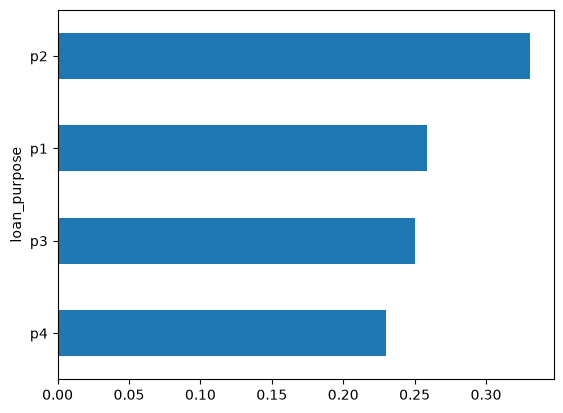

In [19]:
df.groupby('loan_purpose')['status'].mean().sort_values().plot(kind='barh')

<Axes: xlabel='credit_score', ylabel='Density'>

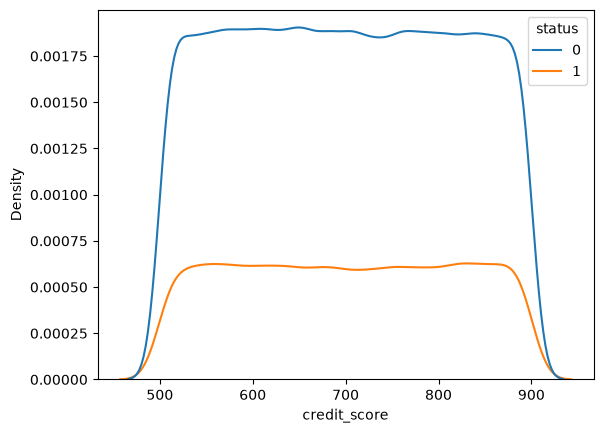

In [20]:
sns.kdeplot(data=df, x='credit_score', hue='status')

<Axes: >

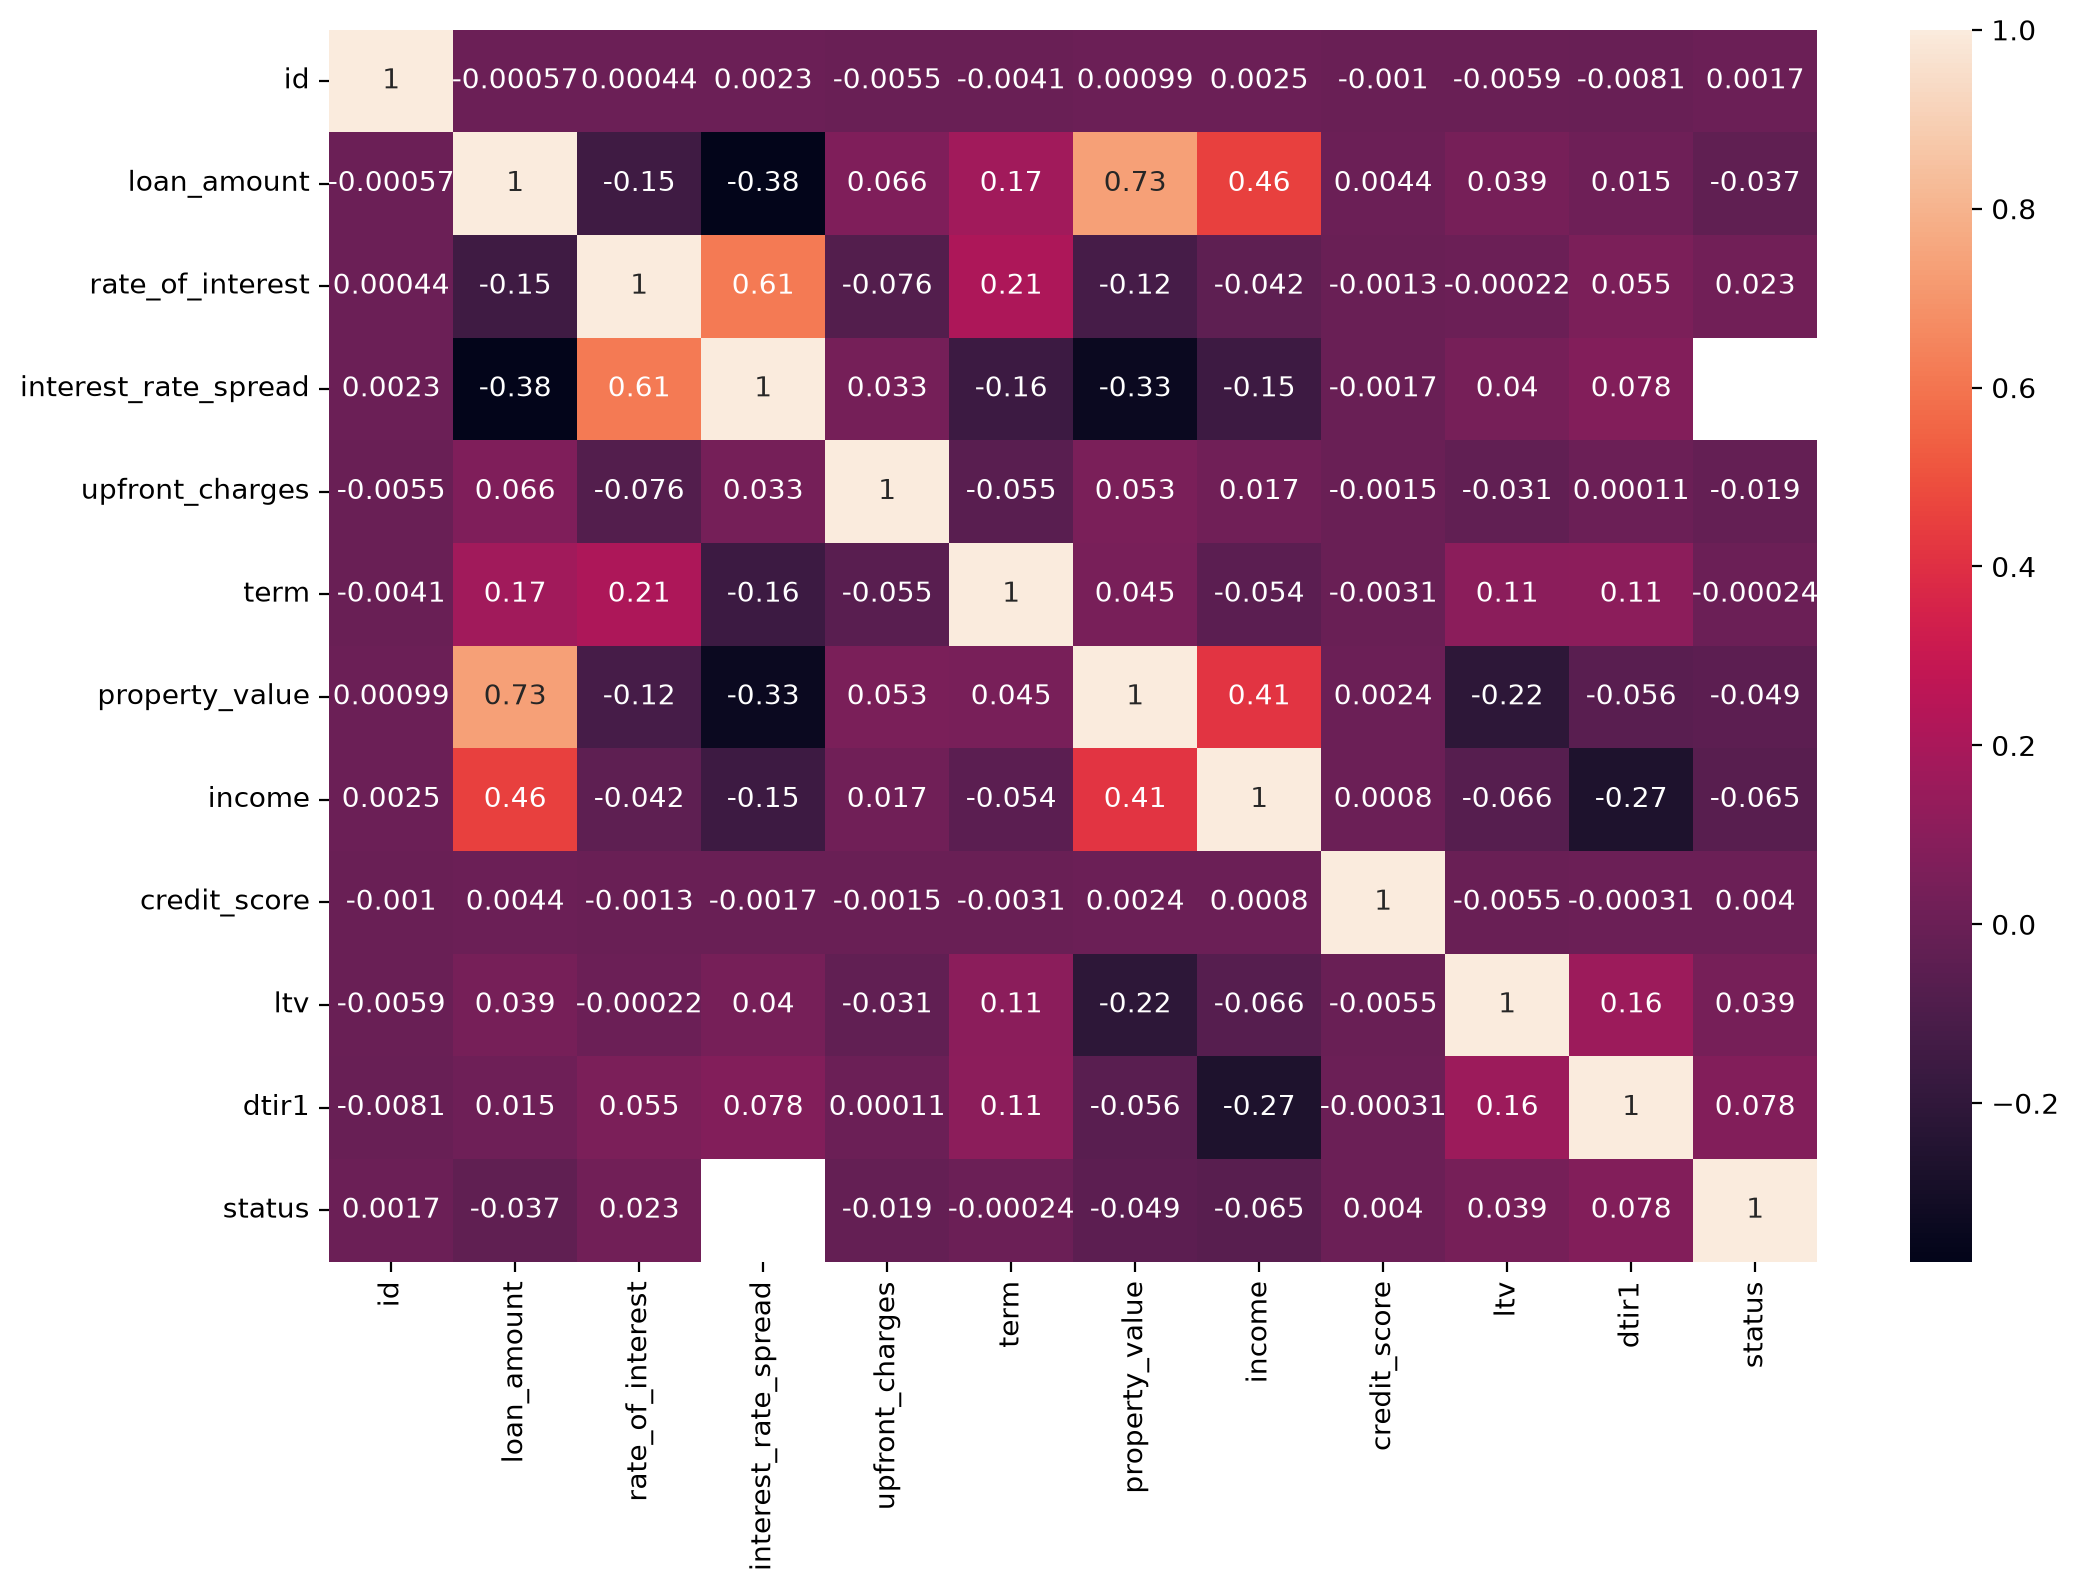

In [21]:
ax, fig = plt.subplots(figsize=(12,8), dpi=200)
sns.heatmap(df[list(num_columns) + ['status']].corr(), annot=True)